<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/12_Least_Squares_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Least Squares Applications

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Materi
Bab ini menerapkan *Least Squares* pada masalah nyata seperti prediksi penyewaan sepeda. Kita akan melampaui perhitungan dasar dengan menambahkan teknik canggih seperti regularisasi untuk mencegah overfitting, regresi polinomial untuk menangkap hubungan non linear, dan *Grid Search* untuk optimasi hiperparameter model.

### Topik yang Dibahas:
1. Prediksi Penyewaan Sepeda (Studi Kasus)
2. Multikolinearitas dan Dampaknya
3. Regularisasi (Ridge Regression)
4. Regresi Polinomial
5. Optimasi dengan Grid Search


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# 1. Simulasi Data: Penyewaan sepeda berdasarkan suhu
np.random.seed(42)
suhu = np.linspace(0, 35, 100)
sewa = 20 + 0.5 * suhu + 0.05 * suhu**2 + np.random.normal(0, 5, 100)

X = suhu.reshape(-1, 1)
y = sewa

print("Data simulasi penyewaan sepeda berhasil dibuat.")


Data simulasi penyewaan sepeda berhasil dibuat.


***
## Regresi Polinomial dan Regularisasi

### Penjelasan Teori
Model linear sering kali tidak cukup untuk menangkap tren non linear. Regresi polinomial meningkatkan fleksibilitas model dengan menambahkan fitur pangkat ($x^2, x^3$). Namun, model yang terlalu fleksibel cenderung *overfit*. Regularisasi (seperti Ridge) menambahkan penalti pada koefisien model untuk menjaga agar bobot tetap kecil dan model tetap sederhana.



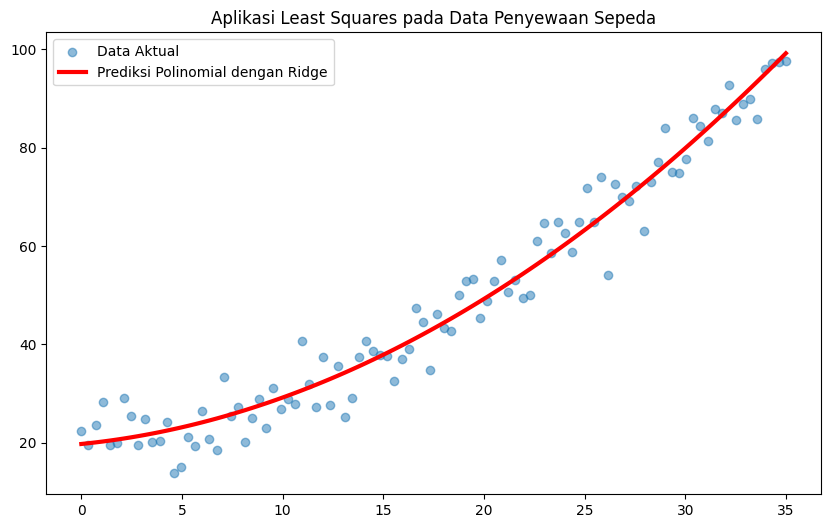

In [2]:
# 2. Regresi Polinomial (Derajat 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 3. Regularisasi (Ridge Regression)
model = Ridge(alpha=1.0)
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

plt.figure(figsize=(10, 6))
plt.scatter(suhu, sewa, label='Data Aktual', alpha=0.5)
plt.plot(suhu, y_pred, color='red', label='Prediksi Polinomial dengan Ridge', linewidth=3)
plt.legend()
plt.title('Aplikasi Least Squares pada Data Penyewaan Sepeda')
plt.show()


***
## Optimasi dengan Grid Search

### Penjelasan Teori
Bagaimana cara menemukan nilai penalti regularisasi (alpha) yang terbaik? Kita menggunakan *Grid Search*. Ini adalah metode sistematis untuk mencoba berbagai nilai parameter secara menyeluruh dan memilih nilai yang memberikan error validasi terkecil.

In [3]:
# 4. Grid Search untuk mencari alpha optimal
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(Ridge(), params, cv=5)
grid.fit(X_poly, y)

print(f"Alpha terbaik hasil Grid Search: {grid.best_params_['alpha']}")


Alpha terbaik hasil Grid Search: 100
